***<center>Análisis de Rentabilidad de Planes Móviles</center>***

# ¿Cuál es la mejor tarifa?

El presente proyecto realiza un análisis analítico para el operador de telecomunicaciones Megaline, con el objetivo de evaluar la rentabilidad de sus dos planes de prepago: Surf y Ultimate. A petición del departamento comercial, la investigación busca determinar cuál de las dos tarifas genera mayores ingresos para guiar la optimización y asignación del presupuesto publicitario de la compañía.

El estudio se basa en una muestra preliminar de 500 clientes durante el año 2018, analizando variables clave como perfiles demográficos, volumen de llamadas, mensajes de texto enviados y consumo de datos.

## Inicialización

In [1]:
# Carga de todas las librerías
import pandas as pd 
import numpy as np
import math as mt
import seaborn as sns
from scipy import stats as st
from matplotlib import pyplot as plt

## Cargar datos

In [2]:
# Carga de los archivos de datos en diferentes DataFrames
users = pd.read_csv("megaline_users.csv")
calls = pd.read_csv("megaline_calls.csv")
messages = pd.read_csv("megaline_messages.csv")
internet = pd.read_csv("megaline_internet.csv")
plans = pd.read_csv("megaline_plans.csv")

## Preparar los datos

Los datos para este proyecto se dividen en varias tablas. Se explorara cada una para tener una comprensión inicial de los datos. Si es necesario, se realizaran las correcciones requeridas en cada tabla.

## Tabla de tarifas

In [3]:
# Impresión de la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Impresión de una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Una vez revisada la información general de los datos, se identificó que la tabla "Plans" únicamente cuenta con dos filas. Por este motivo, no 
resulta relevante aplicar un proceso de muestreo, dado lo reducido del conjunto de datos. En este caso, considero más adecuado presentar la tabla completa, ya que permite observar directamente las dos tarifas disponibles.

Asimismo, dentro de la tabla es posible visualizar la composición de cada plan, incluyendo sus precios mensuales, minutos, mensajes y GB incluidos.

Por otra parte, se identificó que la columna "usd_monthly_pay" se encuentra definida con el tipo de dato int64. Por lo tanto, es mucho mejor tratar estos datos como tipo "float64", esto debido a que dado el caso que se de une excedente dentro del plan, lo podemos calcular al valor real, contando los centavos que se suman por lo excedentes de minutos y mensajes en los dos planes. 

## Corregir datos

In [5]:
# Se hace el cambio de del tipo de datos como se menciono en un principio
plans["usd_monthly_pay"] = plans["usd_monthly_pay"].astype(float)

## Tabla de usuarios/as

In [6]:
# Impresión de la información general/resumida sobre el DataFrame de las users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [7]:
# Impresión de una muestra de datos para usuarios
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
81,1081,Grayce,Sears,44,"Dallas-Fort Worth-Arlington, TX MSA",2018-04-27,surf,NaN
369,1369,Bernard,Mckee,69,"Milwaukee-Waukesha, WI MSA",2018-10-06,surf,NaN
425,1425,Latrisha,Larsen,19,"Las Vegas-Henderson-Paradise, NV MSA",2018-09-20,surf,NaN
493,1493,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaN
43,1043,Carlos,Hinton,42,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-20,ultimate,NaN


A partir de los datos analizados, se logró identificar información relevante de los usuarios, tales como sus nombres, edades, ciudad de adquisición, plan seleccionado, así como las fechas de inicio y cancelación del servicio. También se observó la existencia de diferentes planes disponibles, sin que exista una clara predominancia en alguno de ellos, ya que la elección depende principalmente de las necesidades y la capacidad económica de cada consumidor.

En cuanto a las observaciones técnicas, se identificó que las columnas correspondientes a las fechas de ingreso ("reg_date") y de salida ("churn_date") se encuentran almacenadas con el tipo de dato "object", lo cual no es una buena práctica para este tipo de información. Esta definición limita la posibilidad de realizar un análisis temporal adecuado, como identificar los meses con mayor número de suscripciones o cancelaciones. Por este motivo, se recomienda transformar dichas columnas al tipo DateTime64, garantizando así una manipulación más precisa y eficiente de las fechas. Como tambien el tipo de datos de "user_id" dado que se encuenta como "int64" y lo ideal es que sea un "object" dado que esta identifcación es unica y no se deben llevar operaciones con el mismo.

Por otra parte, en la columna "churn_date" se encontraron valores ausentes, lo cual no se considera una anomalía, ya que corresponde de manera natural al contexto: hace referencia a la fecha de cancelación del plan y, en los casos en los que no existe valor, significa que el servicio permanece activo. En este sentido, se evidenció que 34 de los 500 usuarios han cancelado su plan.

### Corregir los datos

In [8]:
users["reg_date"] = pd.to_datetime(users["reg_date"], format = "%Y-%m-%d")
users["churn_date"] = pd.to_datetime(users["churn_date"], format = "%Y-%m-%d")
users['user_id'] = users['user_id'].astype(object)

### Enriquecer los datos

De la siguiente manera, podemos saber cuales han sido los meses los que se han registrado mas entradas y salidas. Como por ejemplo se puede observar que en el mes de junio, fue el mes en donde mas suscripciones se llevon a cabo mientras que para diciembre, fue donde se registraron mas cancelaciones de planes.

In [9]:
users["months_entry"] = users["reg_date"].dt.month_name()
users["months_departure"] = users["churn_date"].dt.month_name()

In [10]:
print(users["months_entry"].value_counts().head())
print()
print(users["months_departure"].value_counts().head())

months_entry
June        54
January     49
August      47
April       45
February    42
Name: count, dtype: int64

months_departure
December     14
November      9
September     4
October       4
August        2
Name: count, dtype: int64


## Tabla de Llamadas

In [11]:
# Impresión la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Impresión una muestra de datos para las llamadas
calls.sample(5)

,id,user_id,call_date,duration
84398,1311_156,1311,2018-10-16,14.76
32744,1123_102,1123,2018-07-13,6.66
117799,1412_83,1412,2018-11-22,0.00
27225,1103_15,1103,2018-12-18,1.67
114358,1400_711,1400,2018-08-12,10.00


En la tabla se logró observar información relacionada con el identificador único de la llamada, la identificación del usuario, la fecha en que se realizaron las llamadas y la duración de las mismas. Sin embargo, se evidenció que el tipo de dato correspondiente a la columna "call_date" se encuentra definido como "object". Por lo tanto, al igual que en la tabla users, la mejor opción en este caso es convertir dicho campo al tipo DateTime64, lo que permitirá trabajar de manera más eficiente con las fechas y acceder a registros específicos según se requiera. Como tambien el tipo de datos de "user_id" se encuenta como "int64" y lo ideal es que sea un "object" dado que esta identifcación es unica y no se deben llevar operaciones con el mismo.

### Corregir los datos

In [13]:
calls["call_date"] = pd.to_datetime(calls["call_date"], format = "%Y-%m-%d")
calls['user_id'] = calls['user_id'].astype(object)

### Enriquecer los datos

Al crear una columna basada en los meses, se puede observar el comportamiento de los consumidores en cuanto al uso del servicio. En este análisis se identifica que el mes de diciembre registra la mayor cantidad de llamadas, con un total de 30.614, lo cual puede estar relacionado con la época decembrina, donde las familias buscan mantener un mayor contacto entre sí. En contraste, el mes de enero presenta el menor número de registros, con tan solo 172 llamadas, posiblemente debido al retorno de las personas a sus labores habituales después del periodo vacacional.

Asimismo, se evidencia una particularidad interesante: el número de llamadas presenta una tendencia creciente mes a mes, lo que indica que, en términos generales, la frecuencia de uso del servicio aumenta de manera progresiva con el paso de los meses.

In [14]:
calls["months"] = calls["call_date"].dt.month_name()

In [15]:
calls["months"].value_counts().head(12)

months
December     30614
November     24651
October      21064
September    16523
August       13590
July         11105
June          8221
May           5959
April         3442
March         1620
February       774
January        172
Name: count, dtype: int64

## Tabla de Mensajes

In [16]:
# Impresión la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [17]:
# Imprime una muestra de datos para los mensajes
messages.sample(5)

,id,user_id,message_date
30615,1193_248,1193,2018-12-17
30349,1191_54,1191,2018-10-05
41058,1264_128,1264,2018-06-25
10238,1076_552,1076,2018-10-13
28566,1174_356,1174,2018-07-19


En base la tabla de "Messages", podemos observar datos relevantes, referente a la identificacion del usuario, como tambien a la identificacion de la fecha en la que salio el mensaje. Sin embargo, se lo observa un error, con respecto al tipo de datos, especifacmente en la columna "message_date" dado que se encuentra como tipo "Object" y lo adecuado seria que pase a "DateTime64", para poder acceder a fechas especificas. Como tambien el tipo de datos de "user_id" dado que se encuenta como "int64" y lo ideal es que sea un "object" dado que esta identifcación es unica y no se deben llevar operaciones con el mismo.

### Corregir los datos

In [18]:
messages["message_date"] = pd.to_datetime(messages["message_date"], format = "%Y-%m-%d")
messages['user_id'] = messages['user_id'].astype(object)

### Enriquecer los datos

Al crear una columna basada en los meses, se puede observar el comportamiento de los consumidores en cuanto al uso del servicio. En este análisis se identifica que el mes de diciembre registra la mayor cantidad de mensajes, con un total de 19.071, lo cual puede estar relacionado con la época decembrina, donde las familias buscan mantener un mayor contacto entre sí. En contraste, el mes de enero presenta el menor número de registros, con tan solo 83 mensajes, posiblemente debido al retorno de las personas a sus labores habituales después del periodo vacacional.

Asi mismo, se evidencia la misma particularidad ocurrida en la tabla de "calls" donde el número de mensajes presenta una tendencia creciente mes a mes, lo que indica que, en términos generales, la frecuencia de uso del servicio aumenta de manera progresiva con el paso de los meses. Lo que quiere decir que estas acciones de llamadas y mensajes estan directamente realacionadas con el comportamiento de los consumidores.

In [19]:
messages["months"] = messages["message_date"].dt.month_name()

In [20]:
messages["months"].value_counts().head(12)

months
December     19071
November     14068
October      12201
September     9227
August        7394
July          5208
June          3833
May           2780
April         1333
March          594
February       259
January         83
Name: count, dtype: int64

## Tabla Internet

In [21]:
# Impresión la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [22]:
# Impresión una muestra de datos para el tráfico de internet
internet.sample(5)

,id,user_id,session_date,mb_used
80920,1377_345,1377,2018-11-22,0.00
27021,1126_0,1126,2018-07-11,664.33
90322,1416_52,1416,2018-10-24,163.65
57438,1258_598,1258,2018-10-29,457.46
90699,1417_381,1417,2018-09-07,176.34


En base la tabla de "internet", podemos observar datos relevantes, referente a la identificacion del usuario, como tambien a la identificacion de la fecha en la que inicio sesión en la web web. Sin embargo, se lo observa un error, con respecto al tipo de datos, especifacmente en la columna "message_date" dado que se encuentra como tipo "Object" y lo adecuado seria que pase a "DateTime64", para poder acceder a fechas especificas. Como tambien el tipo de datos de "user_id" dado que se encuenta como "int64" y lo ideal es que sea un "object" dado que esta identifcación es unica y no se deben llevar operaciones con el mismo.

### Corregir los datos

In [23]:
internet['user_id'] = internet['user_id'].astype(object)
internet["session_date"] = pd.to_datetime(internet["session_date"], format = "%Y-%m-%d")

### Enriquecer los datos

Al crear una columna basada en los meses, se puede analizar el comportamiento de los consumidores en cuanto al uso del servicio. En este caso, se observa que el mes de diciembre registra la mayor cantidad de inicios de sesión en la web, con un total de 23.492. Este comportamiento puede estar asociado a la temporada decembrina, donde es común un mayor número de búsquedas relacionadas con regalos, viajes o incluso un incremento en el acceso a redes sociales para conocer el comportamiento y actividades de familiares y allegados.

En contraste, el mes de enero presenta el menor número de registros, con tan solo 96 inicios de sesión, lo cual posiblemente se deba al regreso de las personas a sus actividades laborales y cotidianas después del periodo vacacional.

De manera similar a lo identificado en las tablas “calls” y “messages”, se evidencia una tendencia creciente mes a mes en el número de inicios de sesión. Esto indica que, en términos generales, la frecuencia de uso del servicio aumenta progresivamente con el paso del tiempo. En consecuencia, puede inferirse que las acciones de llamadas, envío de mensajes y navegación en internet están directamente relacionadas con el comportamiento de los consumidores.

In [24]:
internet["months"] = internet["session_date"].dt.month_name()

In [25]:
internet["months"].value_counts().head(12)

months
December     23492
November     18651
October      16193
September    12722
August       10718
July          8110
June          6057
May           4288
April         2558
March         1336
February       604
January         96
Name: count, dtype: int64

## Estudio de las condiciones de las tarifas

Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción.

In [26]:
# Impresión las condiciones de la tarifa y asegúrate de que te quedan claras
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20.0,10,0.03,0.03,surf
1,1000,30720,3000,70.0,7,0.01,0.01,ultimate


## Agregar datos por usuario

Ahora que los datos están limpios, se agregara los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo.

In [27]:
# Calculo del número de llamadas hechas por cada usuario al mes.
number_calls = calls.groupby(['user_id', 'months'])['id'].count().reset_index()
number_calls.columns = ['user_id', 'months', 'calls_count']
number_calls.head()

,user_id,months,calls_count
0,1000,December,16
1,1001,August,27
2,1001,December,56
3,1001,November,64
4,1001,October,65


In [28]:
# Calculo de la cantidad de minutos usados por cada usuario al mes.
calls['duration_rounded'] = np.ceil(calls['duration'])
number_minutes = calls.groupby(['user_id', 'months'])['duration_rounded'].sum().reset_index()
number_minutes.columns = ['user_id', 'months', 'minutes_sum']
number_minutes.head()

,user_id,months,minutes_sum
0,1000,December,124.0
1,1001,August,182.0
2,1001,December,412.0
3,1001,November,426.0
4,1001,October,393.0


In [29]:
# Calculo del número de mensajes enviados por cada usuario al mes.
number_messages = messages.groupby(['user_id', 'months'])['id'].count().reset_index()
number_messages.columns = ['user_id', 'months', 'messages_count']
number_messages.head()

,user_id,months,messages_count
0,1000,December,11
1,1001,August,30
2,1001,December,44
3,1001,November,36
4,1001,October,53


In [30]:
# Calculo del volumen del tráfico de Internet usado por cada usuario al mes.
vol_internet = internet.groupby(['user_id', 'months'])['mb_used'].sum().reset_index()
vol_internet.columns = ['user_id', 'months', 'internet_sum']
vol_internet['internet_gb'] = np.ceil(vol_internet['internet_sum'] / 1024)
vol_internet = vol_internet.drop('internet_sum', axis=1)
vol_internet.head()

,user_id,months,internet_gb
0,1000,December,2.0
1,1001,August,7.0
2,1001,December,19.0
3,1001,November,19.0
4,1001,October,22.0


Se debe juntar los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.

In [31]:
# Fusión los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
final_df = number_calls.merge(number_minutes, on=['user_id', 'months'], how='outer')
final_df = final_df.merge(number_messages, on=['user_id', 'months'], how='outer')
final_df = final_df.merge(vol_internet, on=['user_id', 'months'], how='outer')
final_df.head()

,user_id,months,calls_count,minutes_sum,messages_count,internet_gb
0,1000,December,16.0,124.0,11.0,2.0
1,1001,August,27.0,182.0,30.0,7.0
2,1001,December,56.0,412.0,44.0,19.0
3,1001,November,64.0,426.0,36.0,19.0
4,1001,October,65.0,393.0,53.0,22.0


In [32]:
# Se añade la información de la tarifa
if 'plan' in final_df.columns:
    final_df = final_df.drop('plan', axis=1)
final_df = final_df.merge(users[["user_id", "plan"]], on='user_id', how='left')
final_df.head()

,user_id,months,calls_count,minutes_sum,messages_count,internet_gb,plan
0,1000,December,16.0,124.0,11.0,2.0,ultimate
1,1001,August,27.0,182.0,30.0,7.0,surf
2,1001,December,56.0,412.0,44.0,19.0,surf
3,1001,November,64.0,426.0,36.0,19.0,surf
4,1001,October,65.0,393.0,53.0,22.0,surf


In [33]:
# Calculo del ingreso mensual para cada usuario
def calcular_ingreso_mensual(row):
    plan = row['plan']
    
    if plan == 'surf':
        limite_minutos = 500
        limite_sms = 50
        limite_gb = 15
        precio_minuto = 0.03
        precio_sms = 0.03
        precio_gb = 10
        tarifa_base = 20
        
    elif plan == 'ultimate':
        limite_minutos = 3000
        limite_sms = 1000
        limite_gb = 30
        precio_minuto = 0.01
        precio_sms = 0.01
        precio_gb = 7
        tarifa_base = 70
    
    exceso_minutos = max(0, row['minutes_sum'] - limite_minutos)
    exceso_sms = max(0, row['messages_count'] - limite_sms)
    exceso_gb = max(0, row['internet_gb'] - limite_gb)
    
    cargo_minutos = exceso_minutos * precio_minuto
    cargo_sms = exceso_sms * precio_sms
    cargo_datos = exceso_gb * precio_gb
    
    return tarifa_base + cargo_minutos + cargo_sms + cargo_datos

final_df['revenue'] = final_df.apply(calcular_ingreso_mensual, axis=1)

In [34]:
final_df.head()

,user_id,months,calls_count,minutes_sum,messages_count,internet_gb,plan,revenue
0,1000,December,16.0,124.0,11.0,2.0,ultimate,70.00
1,1001,August,27.0,182.0,30.0,7.0,surf,20.00
2,1001,December,56.0,412.0,44.0,19.0,surf,60.00
3,1001,November,64.0,426.0,36.0,19.0,surf,60.00
4,1001,October,65.0,393.0,53.0,22.0,surf,90.09


## Estudio del comportamiento de usuario

Se genera el calculo algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Con lo cual se generan gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.

### Llamadas

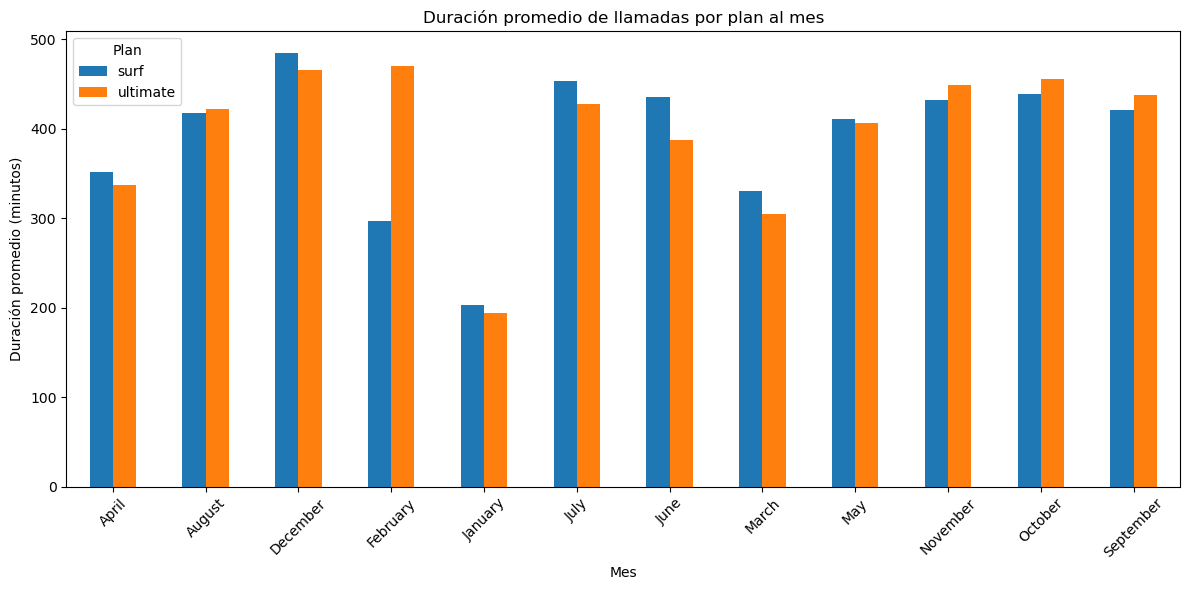

In [35]:
# Comparacion de la duración promedio de llamadas por cada plan y 
# por cada mes. Se traza un gráfico de barras para visualizarla.
duracion_promedio = final_df.groupby(['plan', 'months'])['minutes_sum'].mean().reset_index()

pivot_table = duracion_promedio.pivot(index='months', columns='plan', values='minutes_sum')

pivot_table.plot(kind='bar', figsize=(12, 6), 
                title='Duración promedio de llamadas por plan al mes')
plt.ylabel('Duración promedio (minutos)')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

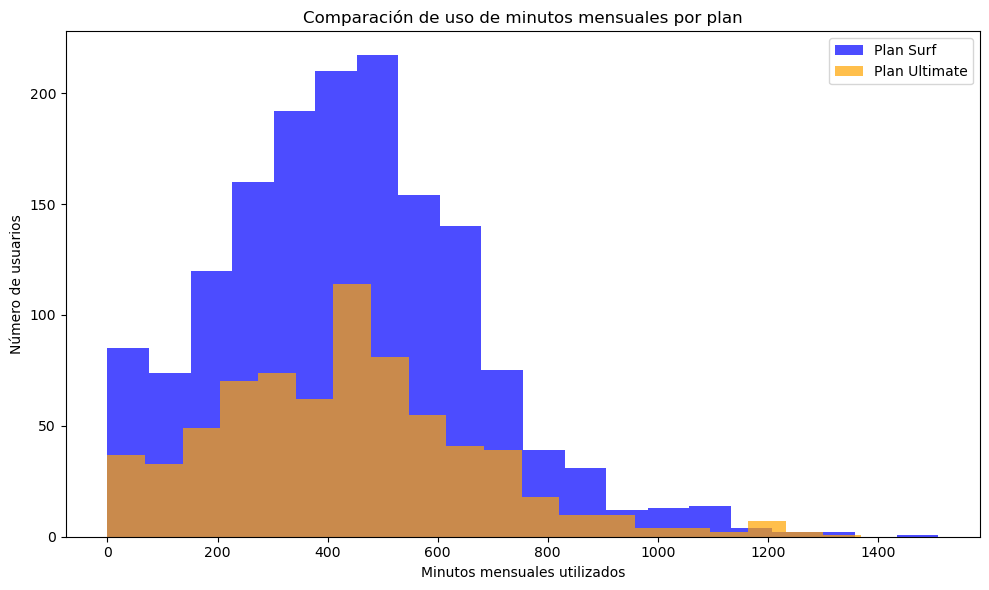

In [36]:
# Comparación del número de minutos mensuales que necesitan los usuarios de cada plan. 
# Se Traza un histograma.
minutos_surf = final_df[final_df['plan'] == 'surf']['minutes_sum']
minutos_ultimate = final_df[final_df['plan'] == 'ultimate']['minutes_sum']

plt.figure(figsize=(10, 6))
plt.hist(minutos_surf, bins=20, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(minutos_ultimate, bins=20, alpha=0.7, label='Plan Ultimate', color='orange')

plt.xlabel('Minutos mensuales utilizados')
plt.ylabel('Número de usuarios')
plt.title('Comparación de uso de minutos mensuales por plan')
plt.legend()
plt.tight_layout()
plt.show()

Se calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.

In [37]:
# Calculo de la media y la varianza de la duración mensual de llamadas.
duracion_promedio = final_df.groupby('plan')['minutes_sum'].mean()
variance = final_df.groupby('plan')['minutes_sum'].var()
print(duracion_promedio)
print()
print(variance)

plan
surf        436.519741
ultimate    434.676017
Name: minutes_sum, dtype: float64

plan
surf        52571.063243
ultimate    56573.632247
Name: minutes_sum, dtype: float64


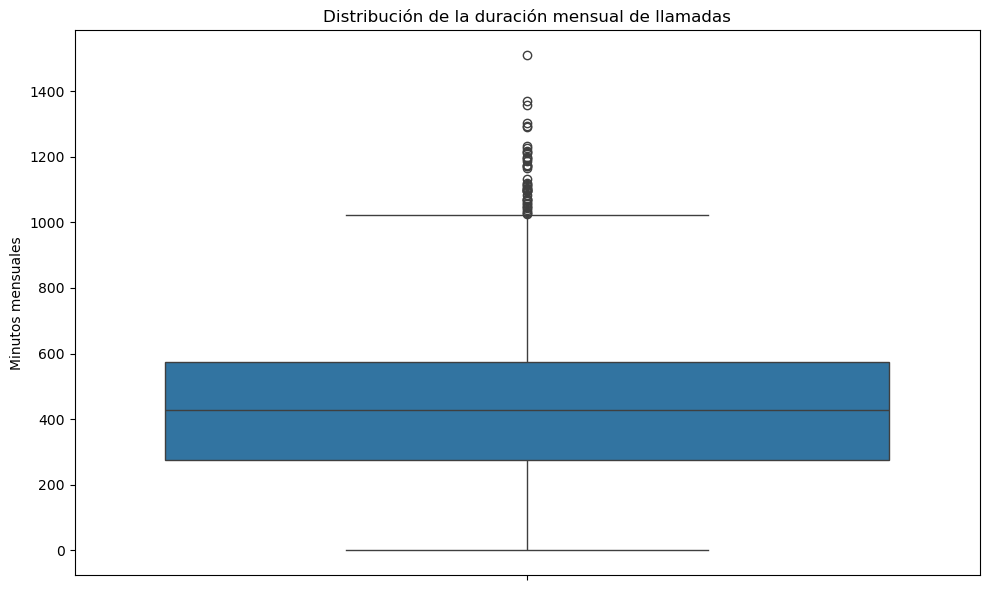

In [38]:
# Se Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, y='minutes_sum')
plt.title('Distribución de la duración mensual de llamadas')
plt.ylabel('Minutos mensuales')
plt.tight_layout()
plt.show()

De las gráficas anteriores se observa que, a pesar de las diferentes condiciones ofrecidas por los planes, los usuarios tanto del plan “Surf” como del plan “Ultimate” presentan un consumo promedio cercano a los 436 y 434 minutos respectivamente mensuales. Esto indica que la mayoría de los consumidores logran disfrutar de los beneficios de sus planes sin incurrir en cobros adicionales por exceder el límite de minutos. No obstante, pueden presentarse casos atípicos o excepcionales asociados a situaciones particulares.

Asimismo, se aprecia un comportamiento similar en la evolución del consumo mensual aunque las medias se mantiene alrededor de los 436 y 434 minutos, en ciertos meses tiende a aumentar, posiblemente influenciado por festividades u otros factores relacionados con el comportamiento individual de los usuarios.

### Mensajes

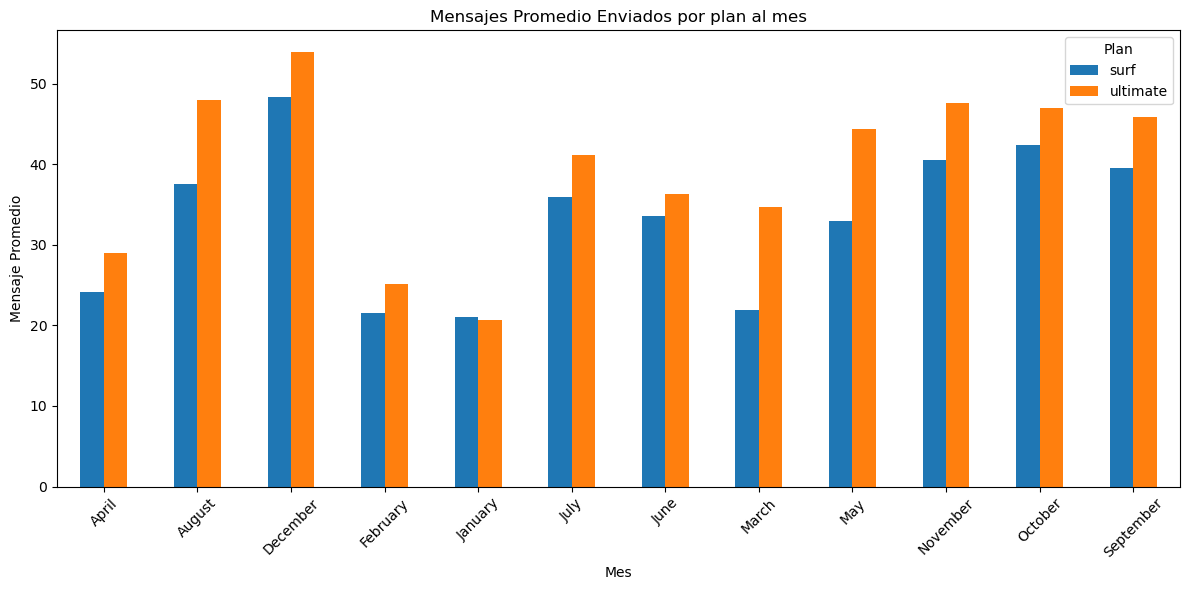

In [39]:
# Comparación el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
mensajes_promedio = final_df.groupby(['plan', 'months'])['messages_count'].mean().reset_index()

pivot_table2 = mensajes_promedio.pivot(index='months', columns='plan', values='messages_count')

pivot_table2.plot(kind='bar', figsize=(12, 6), 
                title='Mensajes Promedio Enviados por plan al mes')
plt.ylabel('Mensaje Promedio')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

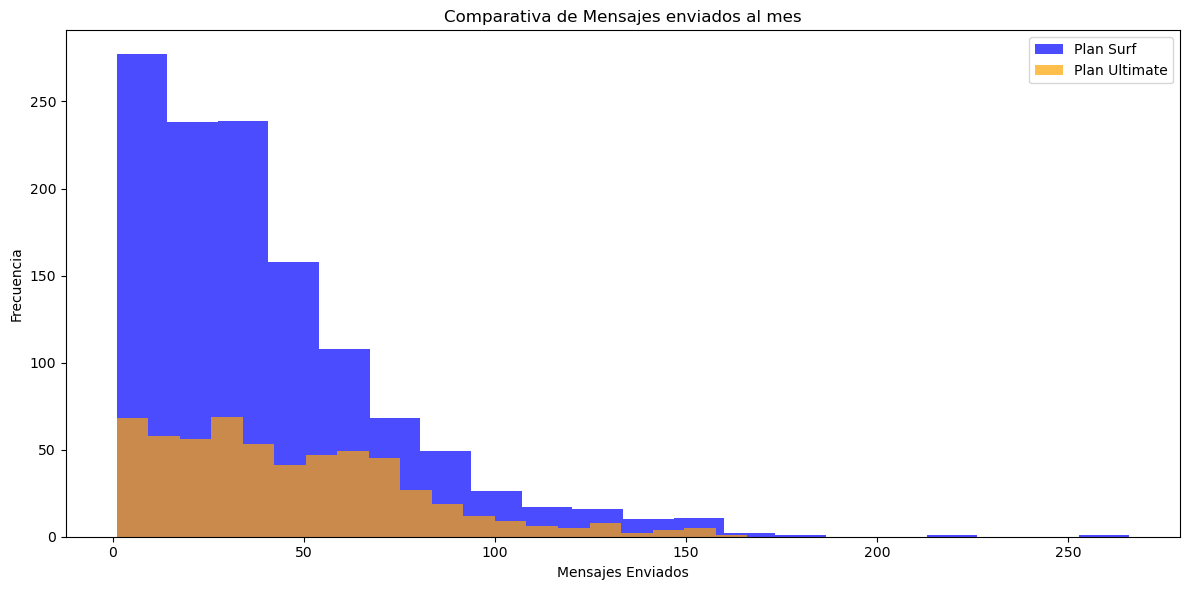

In [40]:
mensajes_surf = final_df[final_df['plan'] == 'surf']['messages_count']
mensajes_ultimate = final_df[final_df['plan'] == 'ultimate']['messages_count']

plt.figure(figsize=(12, 6))
plt.hist(mensajes_surf, bins=20, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(mensajes_ultimate, bins=20, alpha=0.7, label='Plan Ultimate', color='orange')

plt.xlabel('Mensajes Enviados')
plt.ylabel('Frecuencia')
plt.title('Comparativa de Mensajes enviados al mes')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
mensajes_promedio = final_df.groupby('plan')['messages_count'].mean()
variance = final_df.groupby('plan')['minutes_sum'].var()
print(mensajes_promedio)
print()
print(variance)

plan
surf        40.109656
ultimate    46.296233
Name: messages_count, dtype: float64

plan
surf        52571.063243
ultimate    56573.632247
Name: minutes_sum, dtype: float64


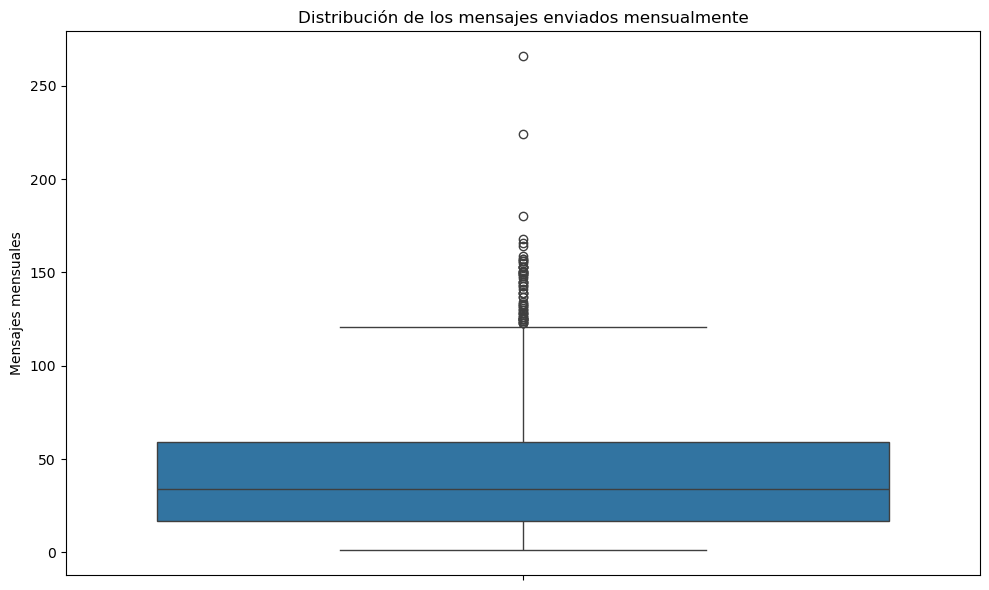

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, y='messages_count')
plt.title('Distribución de los mensajes enviados mensualmente')
plt.ylabel('Mensajes mensuales')
plt.tight_layout()
plt.show()

De las gráficas anteriores se interpreta que los datos relacionados con los mensajes enviados por los usuarios muestran un comportamiento similar entre planes. Aunque, como se mencionó previamente, el plan “Surf” concentra una mayor proporción de suscripciones en comparación con el plan “Ultimate”, la variación en el número de mensajes de texto enviados resulta mínima. En promedio, los usuarios del plan “Surf” envían alrededor de 40 mensajes mensuales, mientras que los del plan “Ultimate” alcanzan aproximadamente 46 mensajes, diferencia que no representa un cambio significativo.

Este comportamiento sugiere que, independientemente del plan contratado, los usuarios mantienen un hábito estable en cuanto al envío de mensajes, estimado en este rango mensual. Sin embargo, pueden presentarse variaciones puntuales relacionadas con factores individuales, fechas especiales o incluso situaciones laborales, que pueden incrementar o disminuir el número de mensajes enviados en determinados periodos.

### Internet

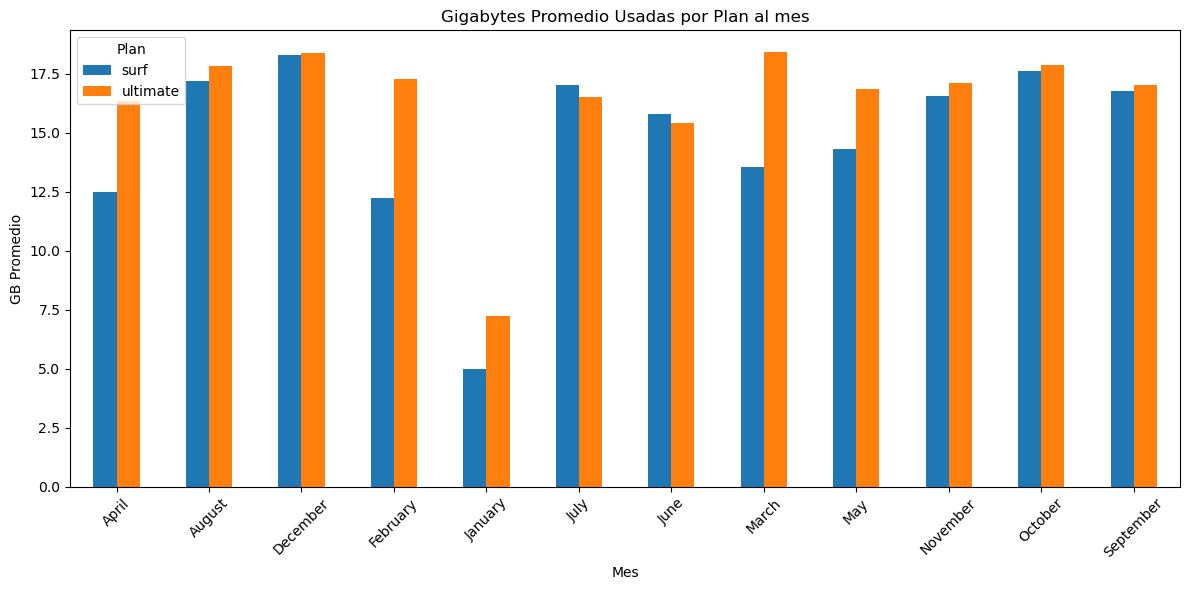

In [43]:
internet_promedio = final_df.groupby(['plan', 'months'])['internet_gb'].mean().reset_index()

pivot_table3 = internet_promedio.pivot(index='months', columns='plan', values='internet_gb')

pivot_table3.plot(kind='bar', figsize=(12, 6), 
                title='Gigabytes Promedio Usadas por Plan al mes')
plt.ylabel('GB Promedio')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

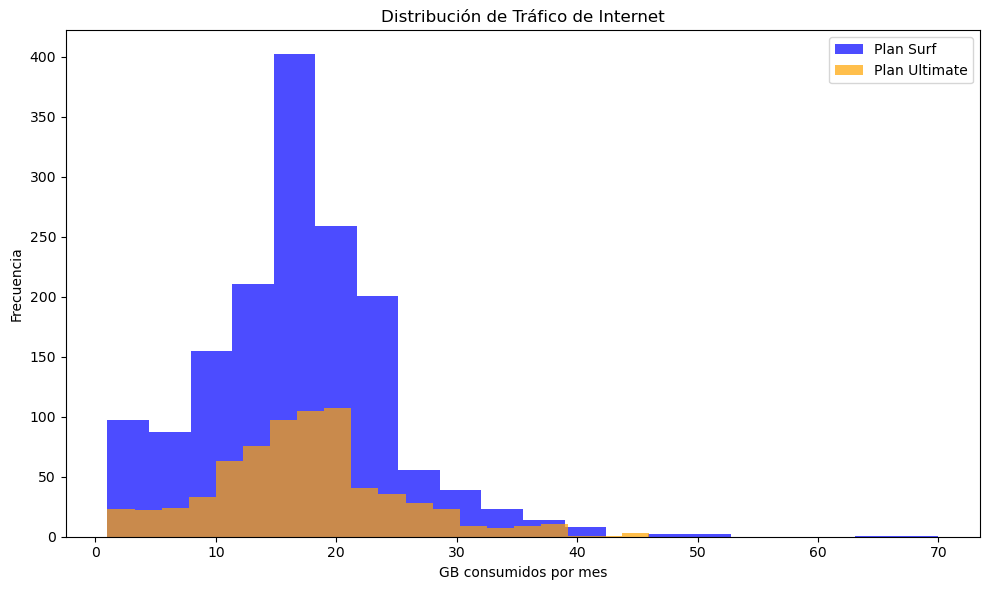

In [44]:
datos_surf = final_df[final_df['plan'] == 'surf']['internet_gb']
datos_ultimate = final_df[final_df['plan'] == 'ultimate']['internet_gb']

plt.figure(figsize=(10, 6))
plt.hist(datos_surf, bins=20, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(datos_ultimate, bins=20, alpha=0.7, label='Plan Ultimate', color='orange')

plt.xlabel('GB consumidos por mes')
plt.ylabel('Frecuencia')
plt.title('Distribución de Tráfico de Internet')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
gb_promedio = final_df.groupby('plan')['internet_gb'].mean()
variance = final_df.groupby('plan')['internet_gb'].var()
print(gb_promedio)
print()
print(variance)

plan
surf        16.831194
ultimate    17.331015
Name: internet_gb, dtype: float64

plan
surf        59.473734
ultimate    58.494733
Name: internet_gb, dtype: float64


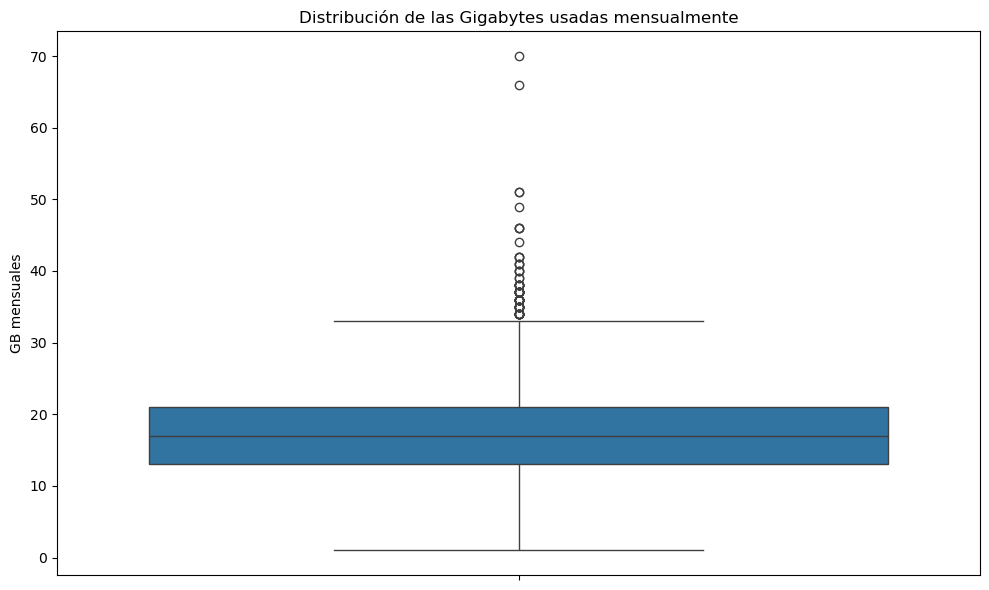

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, y='internet_gb')
plt.title('Distribución de las Gigabytes usadas mensualmente')
plt.ylabel('GB mensuales')
plt.tight_layout()
plt.show()

Como se ha venido evidenciando, a pesar de que los planes ofrecen beneficios distintos a precios diferentes, el comportamiento de los consumidores resulta muy similar en cuanto a sus hábitos de consumo. Aunque el plan “Ultimate” dispone de una mayor cantidad de gigabytes en comparación con el plan “Surf”, podría suponerse que sus usuarios harían un uso significativamente más alto de este recurso. Sin embargo, al analizar los datos, la diferencia es mínima: los usuarios de “Ultimate” consumen en promedio 17 GB mensuales, mientras que los de “Surf” alcanzan alrededor de 16 GB.

Al llegar a este nivel de consumo, los usuarios del plan “Surf” suelen pagar un excedente por datos adicionales, lo que evidencia su necesidad de mantener un mayor acceso a internet. Esta situación depende de las particularidades de cada usuario, ya sea por motivos laborales o de entretenimiento, que pueden llevarlos a requerir más datos de los incluidos en su plan. No obstante, no todos los consumidores alcanzan este punto, ya que también influye la gestión que cada persona haga de su propio consumo.

En conclusión, la variación resulta casi imperceptible y refuerza la idea de que, más allá de las diferencias en los beneficios ofrecidos por cada plan, los hábitos de consumo de los usuarios se mantienen bastante similares.

## Ingreso

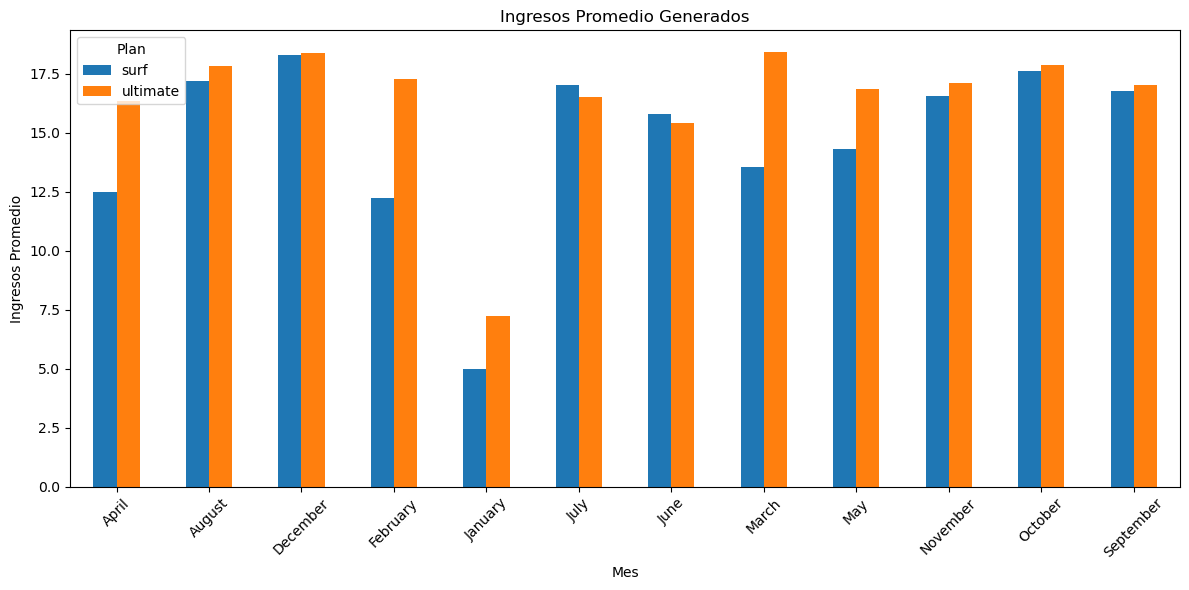

In [47]:
ingresos_promedio = final_df.groupby(['plan', 'months'])['revenue'].mean().reset_index()

pivot_table4 = ingresos_promedio.pivot(index='months', columns='plan', values='revenue')

pivot_table3.plot(kind='bar', figsize=(12, 6), 
                title='Ingresos Promedio Generados')
plt.ylabel('Ingresos Promedio')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

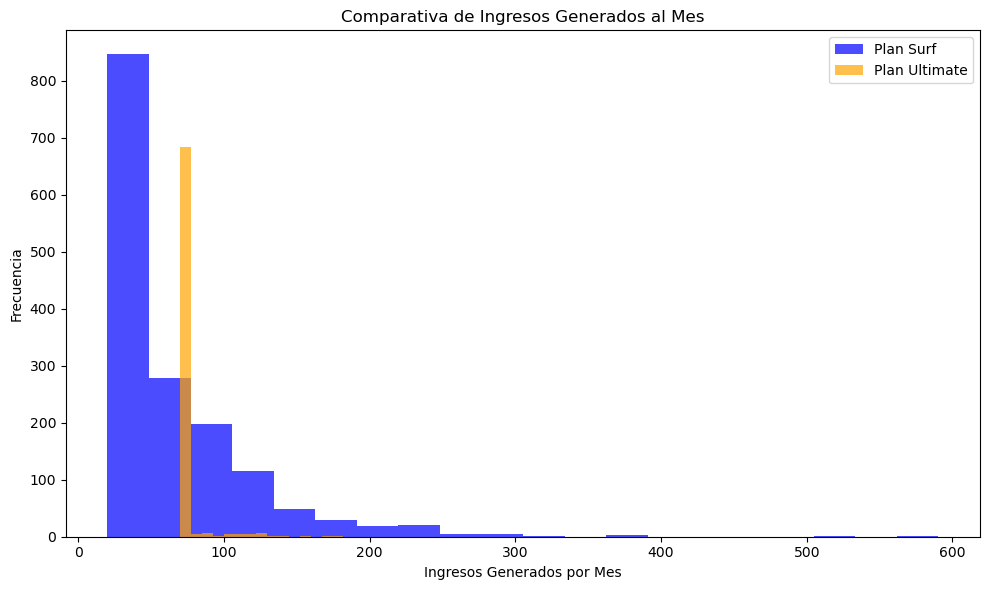

In [48]:
datos_surf = final_df[final_df['plan'] == 'surf']['revenue']
datos_ultimate = final_df[final_df['plan'] == 'ultimate']['revenue']

plt.figure(figsize=(10, 6))
plt.hist(datos_surf, bins=20, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(datos_ultimate, bins=15, alpha=0.7, label='Plan Ultimate', color='orange')

plt.xlabel('Ingresos Generados por Mes')
plt.ylabel('Frecuencia')
plt.title('Comparativa de Ingresos Generados al Mes')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
ingresos_promedio = final_df.groupby('plan')['revenue'].mean()
variance = final_df.groupby('plan')['revenue'].var()
print(ingresos_promedio)
print()
print(variance)

plan
surf        60.706408
ultimate    72.313889
Name: revenue, dtype: float64

plan
surf        3067.835152
ultimate     129.848486
Name: revenue, dtype: float64


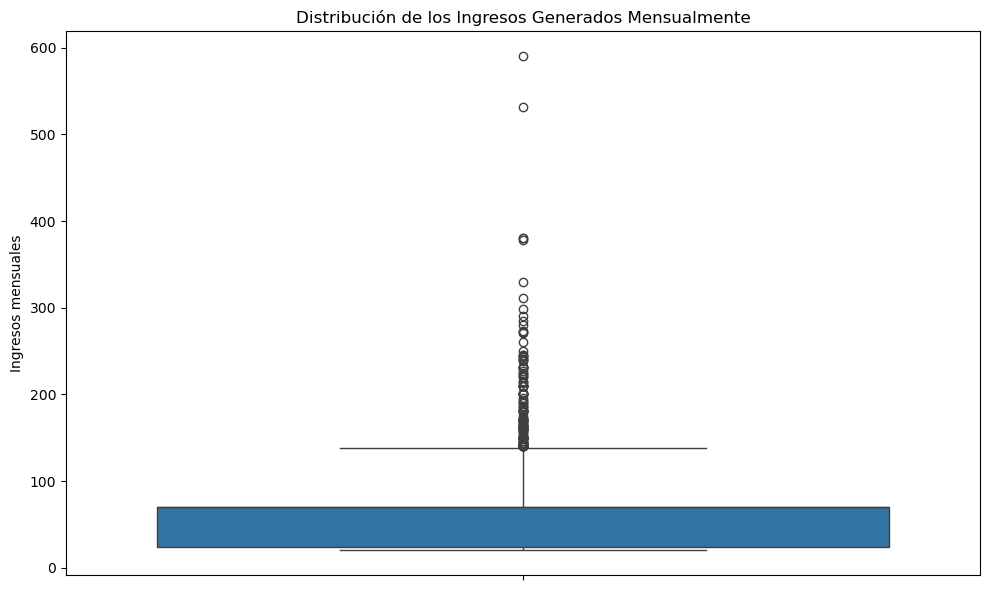

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, y='revenue')
plt.title('Distribución de los Ingresos Generados Mensualmente')
plt.ylabel('Ingresos mensuales')
plt.tight_layout()
plt.show()

Teniendo en cuenta los precios de los planes, a simple vista podría suponerse que el plan “Ultimate” generaría mayores ingresos que el plan “Surf”. Sin embargo, es necesario considerar otros factores, como el número de suscriptores. En este sentido, se ha observado que gran parte del movimiento económico proviene del plan “Surf”, que al ser más accesible concentra un mayor número de usuarios, lo que incrementa significativamente sus ingresos.

Otro aspecto relevante son los pagos por excedentes. Tal como se evidenció en el caso del consumo de internet, muchos usuarios estaban dispuestos a pagar 10 dólares adicionales para obtener más datos, además de casos excepcionales en los que podían gastar aún más, ya fuera en gigabytes, mensajes de texto o minutos adicionales.

De esta manera, al analizar tanto las gráficas como las medias, se concluye que el plan “Surf” genera ingresos superiores en proporción a su precio. Aunque su valor estandarizado es de 20 dólares mensuales, teniendo en cuenta los factores mencionados, alcanza ingresos cercanos a 60 dólares por usuario al mes, lo que lo convierte en un plan altamente rentable. En comparación, el plan “Ultimate” genera aproximadamente 72 dólares mensuales por usuario, lo que representa apenas un excedente de 2 dólares sobre su precio estándar de 70 dólares.

Esto evidencia que, para la organización, el plan “Surf” resulta más rentable debido a su mayor alcance entre el público y a la disposición de los usuarios a realizar pagos por excedentes de manera eventual. Cabe señalar que los ingresos del plan “Ultimate” se concentran más cerca de la media, mientras que los del plan “Surf” presentan una mayor dispersión, influenciada por las particularidades de consumo y los pagos adicionales asumidos por sus usuarios.

## Prueba las hipótesis estadísticas

Prueba de hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.

In [51]:
# Prueba las hipótesis
#Hipotesis nula es que los ingresos promedio precedentes de los usuarios de los planes llamada Ultimate y Surf son igules
#Hipotesis alternativa es es que los ingresos promedio precedentes de los usuarios de los planes llamada Ultimate y Surf son diferentes
datos_surf = final_df[final_df['plan'] == 'surf']['revenue']
datos_ultimate = final_df[final_df['plan'] == 'ultimate']['revenue']

alpha = 0.05

results = st.ttest_ind(datos_surf, datos_ultimate)

print('valor p: ', results.pvalue)

if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  2.8626745106986436e-08
Rechazamos la hipótesis nula


Prueba de hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

In [52]:
# Prueba las hipótesis
# Hipotesis nula es que el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
# Hipotesis alternativa es el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.
usuarios_ny_nj_ids = users[users['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['user_id']

ingresos_ny_nj = final_df[final_df['user_id'].isin(usuarios_ny_nj_ids)]['revenue']

usuarios_otras_regiones_ids = users[users['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['user_id']
ingresos_otras_regiones = final_df[final_df['user_id'].isin(usuarios_otras_regiones_ids)]['revenue']

alpha = 0.05

results = st.ttest_ind(ingresos_ny_nj, ingresos_otras_regiones)

print('valor p: ', results.pvalue)

if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  0.043557431621342436
Rechazamos la hipótesis nula


## Conclusión general

Una vez realizado el análisis de la información proporcionada por la organización Megaline, en primera instancia fue necesario enriquecer los datos dividiendo ciertas columnas, especialmente las relacionadas con las fechas de los usuarios. Esto permitió identificar meses específicos de consumo y, a partir de allí, realizar comparativas más precisas.

Asimismo, se generó un aproximado de los ingresos percibidos por los planes “Surf” y “Ultimate”, teniendo en cuenta factores como los pagos por excedentes. Para ello, fue indispensable transformar los valores de MB a GB, ya que, según la información inicial, al superar los 1025 MB se aplicaba un cobro adicional en ambos planes. Esta conversión facilitó un cálculo más exacto sobre los ingresos derivados de dichos excedentes.

En cuanto a las comparativas de consumo, se observó que, a pesar de tratarse de planes con beneficios distintos, los usuarios presentaban comportamientos muy similares en sus hábitos de uso. También se identificó cierta estacionalidad en el consumo, ya que las fechas de mayor actividad en SMS, llamadas e internet coincidieron con la época decembrina, asociada a vacaciones, reuniones familiares y actividades sociales.

Una particularidad relevante se encontró en el consumo de internet: los usuarios del plan “Surf” mostraron una mayor disposición a pagar por excedentes con el fin de obtener gigabytes adicionales, lo que explica por qué este plan llegó a generar más del doble de lo que debería producir en condiciones estándar, debido a que, en promedio, los usuarios estaban dispuestos a realizar pagos adicionales.

En conclusión, este análisis permitió evidenciar que los ingresos de ambos planes no eran equivalentes, ya que presentaban una varianza significativa. Si bien los beneficios y precios de cada plan eran diferentes, los patrones de consumo resultaron ser muy similares, siendo los pagos por excedentes especialmente en el plan “Surf” un factor decisivo para comprender la rentabilidad real de los servicios.